In [62]:
from pathlib import Path
import pandas as pd
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from xgboost import XGBRegressor
from sklearn.preprocessing import FunctionTransformer
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.compose import TransformedTargetRegressor
import time

# 1. Read the train, valid and test dataframes that were already stratified and stored

In [11]:
train_df = pd.read_csv(r'C:\Users\Rahul\OneDrive\Desktop\Learning\Projects\nyc_taxi\processed\stratified_sample_rng42\train_df.csv', index_col=0)
valid_df = pd.read_csv(r'C:\Users\Rahul\OneDrive\Desktop\Learning\Projects\nyc_taxi\processed\stratified_sample_rng42\valid_df.csv', index_col=0)
test_df = pd.read_csv(r'C:\Users\Rahul\OneDrive\Desktop\Learning\Projects\nyc_taxi\processed\stratified_sample_rng42\test_df.csv', index_col=0)
print('train_df.shape', train_df.shape)
print('valid_df.shape', valid_df.shape)
print('test_df.shape', test_df.shape)

train_df.shape (480000, 12)
valid_df.shape (150000, 12)
test_df.shape (150000, 12)


# 3. Create a function run Experiments efficiently

In [18]:
def run_xgb_experiment(
    name,
    train_df,
    valid_df,
    test_df,
    numeric_features,
    categorical_features,
    target_col="fare_amount",
    log_target=False,
    params=None,
):
    if params is None:
        params = dict(
            n_estimators=300,
            max_depth=8,
            learning_rate=0.08,
            subsample=0.8,
            colsample_bytree=0.8,
            min_child_weight=1,
            objective="reg:squarederror",
            eval_metric="rmse",
            random_state=42,
            n_jobs=-1,
        )

    X_train = train_df[numeric_features + categorical_features].copy()
    y_train = train_df[target_col].copy()

    X_valid = valid_df[numeric_features + categorical_features].copy()
    y_valid = valid_df[target_col].copy()

    X_test = test_df[numeric_features + categorical_features].copy()
    y_test = test_df[target_col].copy()

    numeric_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
    ])

    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="constant", fill_value="MISSING")),
        ("to_string", FunctionTransformer(lambda x: x.astype(str))),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numeric_features),
            ("cat", categorical_transformer, categorical_features),
        ]
    )

    model = XGBRegressor(**params)

    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model),
    ])

    if log_target:
        y_train_fit = np.log1p(y_train)
        pipeline.fit(X_train, y_train_fit)

        valid_pred = np.expm1(pipeline.predict(X_valid))
        test_pred = np.expm1(pipeline.predict(X_test))

        valid_pred = np.clip(valid_pred, 0, None)
        test_pred = np.clip(test_pred, 0, None)
    else:
        pipeline.fit(X_train, y_train)
        valid_pred = pipeline.predict(X_valid)
        test_pred = pipeline.predict(X_test)

    valid_mae = mean_absolute_error(y_valid, valid_pred)
    valid_rmse = np.sqrt(mean_squared_error(y_valid, valid_pred))
    test_mae = mean_absolute_error(y_test, test_pred)
    test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))

    return {
        "experiment": name,
        "valid_mae": valid_mae,
        "valid_rmse": valid_rmse,
        "test_mae": test_mae,
        "test_rmse": test_rmse,
    }

In [32]:
import numpy as np
import pandas as pd

train_base = train_df.copy()
valid_base = valid_df.copy()
test_base = test_df.copy()

# Set up the feeatures required for different experiments

In [35]:
def prepare_experiment_dfs(
    train_df,
    valid_df,
    test_df,
    use_pu_do=True,
    use_pu_do_pair=False,
    use_route_frequency=False,
    use_airport_flags=False,
    use_cyclical=False,
):
    train = train_df.copy()
    valid = valid_df.copy()
    test = test_df.copy()

    # ------------------------------
    # Base features
    # ------------------------------
    numeric_features = [
        "trip_distance",
        "passenger_count",
        "pickup_hour",
        "pickup_weekday",
        "pickup_month",
    ]

    categorical_features = [
        "VendorID",
        "RatecodeID",
        "store_and_fwd_flag",
    ]

    if use_pu_do:
        categorical_features += ["PULocationID", "DOLocationID"]

    # ------------------------------
    # PU_DO_pair
    # ------------------------------
    if use_pu_do_pair:
        for df in [train, valid, test]:
            df["PU_DO_pair"] = (
                df["PULocationID"].astype(str) + "_" + df["DOLocationID"].astype(str)
            )
        categorical_features.append("PU_DO_pair")

    # ------------------------------
    # Route frequency (train-derived only)
    # ------------------------------
    if use_route_frequency:
        for df in [train, valid, test]:
            df["route"] = (
                df["PULocationID"].astype(str) + "_" + df["DOLocationID"].astype(str)
            )

        route_count_map = train["route"].value_counts().to_dict()

        train["route_train_count"] = train["route"].map(route_count_map).fillna(0)
        valid["route_train_count"] = valid["route"].map(route_count_map).fillna(0)
        test["route_train_count"] = test["route"].map(route_count_map).fillna(0)

        train["route_train_count_log"] = np.log1p(train["route_train_count"])
        valid["route_train_count_log"] = np.log1p(valid["route_train_count"])
        test["route_train_count_log"] = np.log1p(test["route_train_count"])

        numeric_features.append("route_train_count_log")

    # ------------------------------
    # Airport flags
    # ------------------------------
    if use_airport_flags:
        AIRPORT_ZONES = {
            "JFK": 132,
            "LGA": 138,
            "EWR": 1,
        }

        for df in [train, valid, test]:
            df["is_jfk_trip"] = (
                (df["PULocationID"] == AIRPORT_ZONES["JFK"]) |
                (df["DOLocationID"] == AIRPORT_ZONES["JFK"])
            ).astype(int)

            df["is_lga_trip"] = (
                (df["PULocationID"] == AIRPORT_ZONES["LGA"]) |
                (df["DOLocationID"] == AIRPORT_ZONES["LGA"])
            ).astype(int)

            df["is_ewr_trip"] = (
                (df["PULocationID"] == AIRPORT_ZONES["EWR"]) |
                (df["DOLocationID"] == AIRPORT_ZONES["EWR"])
            ).astype(int)

            df["is_any_airport_trip"] = (
                df["is_jfk_trip"] | df["is_lga_trip"] | df["is_ewr_trip"]
            ).astype(int)

        numeric_features += [
            "is_jfk_trip",
            "is_lga_trip",
            "is_ewr_trip",
            "is_any_airport_trip",
        ]

    # ------------------------------
    # Cyclical encoding
    # ------------------------------
    if use_cyclical:
        for df in [train, valid, test]:
            df["pickup_hour_sin"] = np.sin(2 * np.pi * df["pickup_hour"] / 24)
            df["pickup_hour_cos"] = np.cos(2 * np.pi * df["pickup_hour"] / 24)

            df["pickup_month_sin"] = np.sin(2 * np.pi * df["pickup_month"] / 12)
            df["pickup_month_cos"] = np.cos(2 * np.pi * df["pickup_month"] / 12)

        # replace raw hour/month with cyclical representation
        numeric_features = [
            f for f in numeric_features if f not in ["pickup_hour", "pickup_month"]
        ]
        numeric_features += [
            "pickup_hour_sin",
            "pickup_hour_cos",
            "pickup_month_sin",
            "pickup_month_cos",
        ]

    return train, valid, test, numeric_features, categorical_features

# Experiment Defining Function

In [34]:
def run_xgb_experiment(
    name,
    train_df,
    valid_df,
    test_df,
    numeric_features,
    categorical_features,
    target_col="fare_amount",
    log_target=False,
    params=None,
):
    if params is None:
        params = dict(
            n_estimators=300,
            max_depth=8,
            learning_rate=0.08,
            subsample=0.8,
            colsample_bytree=0.8,
            min_child_weight=1,
            objective="reg:squarederror",
            eval_metric="rmse",
            random_state=42,
            n_jobs=-1,
        )

    X_train = train_df[numeric_features + categorical_features].copy()
    y_train = train_df[target_col].copy()

    X_valid = valid_df[numeric_features + categorical_features].copy()
    y_valid = valid_df[target_col].copy()

    X_test = test_df[numeric_features + categorical_features].copy()
    y_test = test_df[target_col].copy()

    numeric_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
    ])

    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="constant", fill_value="MISSING")),
        ("to_string", FunctionTransformer(lambda x: x.astype(str))),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numeric_features),
            ("cat", categorical_transformer, categorical_features),
        ]
    )

    model = XGBRegressor(**params)

    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model),
    ])

    if log_target:
        y_train_fit = np.log1p(y_train)
        pipeline.fit(X_train, y_train_fit)

        valid_pred = np.expm1(pipeline.predict(X_valid))
        test_pred = np.expm1(pipeline.predict(X_test))

        valid_pred = np.clip(valid_pred, 0, None)
        test_pred = np.clip(test_pred, 0, None)
    else:
        pipeline.fit(X_train, y_train)
        valid_pred = pipeline.predict(X_valid)
        test_pred = pipeline.predict(X_test)

    valid_mae = mean_absolute_error(y_valid, valid_pred)
    valid_rmse = np.sqrt(mean_squared_error(y_valid, valid_pred))
    test_mae = mean_absolute_error(y_test, test_pred)
    test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))

    return {
        "experiment": name,
        "valid_mae": valid_mae,
        "valid_rmse": valid_rmse,
        "test_mae": test_mae,
        "test_rmse": test_rmse,
    }

# Run the experiments

In [39]:
experiment_specs = [
    {
        "name": "baseline_pu_do",
        "use_pu_do": True,
        "use_pu_do_pair": False,
        "use_route_frequency": False,
        "use_airport_flags": False,
        "use_cyclical": False,
        "log_target": False,
    },
    {
        "name": "with_pu_do_pair",
        "use_pu_do": True,
        "use_pu_do_pair": True,
        "use_route_frequency": False,
        "use_airport_flags": False,
        "use_cyclical": False,
        "log_target": False,
    },
    {
        "name": "with_route_frequency",
        "use_pu_do": True,
        "use_pu_do_pair": False,
        "use_route_frequency": True,
        "use_airport_flags": False,
        "use_cyclical": False,
        "log_target": False,
    },
    {
        "name": "without_pu_do",
        "use_pu_do": False,
        "use_pu_do_pair": False,
        "use_route_frequency": False,
        "use_airport_flags": False,
        "use_cyclical": False,
        "log_target": False,
    },
    {
        "name": "baseline_plus_cyclical",
        "use_pu_do": True,
        "use_pu_do_pair": False,
        "use_route_frequency": False,
        "use_airport_flags": False,
        "use_cyclical": True,
        "log_target": False,
    },
    {
        "name": "baseline_log_target",
        "use_pu_do": True,
        "use_pu_do_pair": False,
        "use_route_frequency": False,
        "use_airport_flags": False,
        "use_cyclical": False,
        "log_target": True,
    },
    {
        "name": "airport_flags_only_no_log",
        "use_pu_do": True,
        "use_pu_do_pair": False,
        "use_route_frequency": False,
        "use_airport_flags": True,
        "use_cyclical": False,
        "log_target": False,
    },
    {
        "name": "airport_flags_plus_log_target",
        "use_pu_do": True,
        "use_pu_do_pair": False,
        "use_route_frequency": False,
        "use_airport_flags": True,
        "use_cyclical": False,
        "log_target": True,
    },
    {
        "name": "airport_flags_plus_pu_do_pair_no_log",
        "use_pu_do": True,
        "use_pu_do_pair": True,
        "use_route_frequency": False,
        "use_airport_flags": True,
        "use_cyclical": False,
        "log_target": False,
    },
    {
        "name": "airport_flags_plus_pu_do_pair_plus_log_target",
        "use_pu_do": True,
        "use_pu_do_pair": True,
        "use_route_frequency": False,
        "use_airport_flags": True,
        "use_cyclical": False,
        "log_target": True,
    },
]

print('done')

done


In [40]:
results = []

for spec in experiment_specs:
    print(f"Running: {spec['name']}")

    tr, va, te, num_feats, cat_feats = prepare_experiment_dfs(
        train_base,
        valid_base,
        test_base,
        use_pu_do=spec["use_pu_do"],
        use_pu_do_pair=spec["use_pu_do_pair"],
        use_route_frequency=spec["use_route_frequency"],
        use_airport_flags=spec["use_airport_flags"],
        use_cyclical=spec["use_cyclical"],
    )

    res = run_xgb_experiment(
        name=spec["name"],
        train_df=tr,
        valid_df=va,
        test_df=te,
        numeric_features=num_feats,
        categorical_features=cat_feats,
        log_target=spec["log_target"],
    )

    results.append(res)

results_df = pd.DataFrame(results).sort_values("test_mae")
#results_df

Running: baseline_pu_do
Running: with_pu_do_pair
Running: with_route_frequency
Running: without_pu_do
Running: baseline_plus_cyclical
Running: baseline_log_target
Running: airport_flags_only_no_log
Running: airport_flags_plus_log_target
Running: airport_flags_plus_pu_do_pair_no_log
Running: airport_flags_plus_pu_do_pair_plus_log_target


In [41]:
results_df.style.format({
    "valid_mae": "{:.4f}",
    "valid_rmse": "{:.4f}",
    "test_mae": "{:.4f}",
    "test_rmse": "{:.4f}",
})

,experiment,valid_mae,valid_rmse,test_mae,test_rmse
5,baseline_log_target,2.2423,4.9067,2.7771,5.6806
7,airport_flags_plus_log_target,2.2467,4.9316,2.7816,5.6878
6,airport_flags_only_no_log,2.2199,4.7503,2.8352,5.7424
4,baseline_plus_cyclical,2.2250,4.7717,2.8361,5.7622
0,baseline_pu_do,2.2209,4.7544,2.8398,5.7670
9,airport_flags_plus_pu_do_pair_plus_log_target,2.2735,4.9646,2.8417,5.8126
1,with_pu_do_pair,2.2448,4.7909,2.8759,5.7854
8,airport_flags_plus_pu_do_pair_no_log,2.2420,4.8112,2.8768,5.8087
2,with_route_frequency,2.2722,4.9042,2.9983,6.1952
3,without_pu_do,2.4095,5.2251,3.0685,6.2832


In [47]:
# Error analysis

# baseline_log_target error analysis

In [ ]:
spec = {
    "name": "baseline_log_target",
    "use_pu_do": True,
    "use_pu_do_pair": False,
    "use_route_frequency": False,
    "use_airport_flags": False,
    "use_cyclical": False,
    "log_target": True
}

target_col="fare_amount"
train_df, valid_df, test_df, numeric_features, categorical_features = prepare_experiment_dfs(
        train_base,
        valid_base,
        test_base,
        use_pu_do=spec["use_pu_do"],
        use_pu_do_pair=spec["use_pu_do_pair"],
        use_route_frequency=spec["use_route_frequency"],
        use_airport_flags=spec["use_airport_flags"],
        use_cyclical=spec["use_cyclical"],
    )

In [66]:
params = dict(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.08,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=1,
    objective="reg:squarederror",
    eval_metric="rmse",
    random_state=42,
    n_jobs=-1,
)

# IMPORTANT: use tr / va / te, not train_df / valid_df / test_df
X_train = train_df[numeric_features + categorical_features].copy()
y_train = train_df[target_col].copy()

X_valid = valid_df[numeric_features + categorical_features].copy()
y_valid = valid_df[target_col].copy()

X_test = test_df[numeric_features + categorical_features].copy()
y_test = test_df[target_col].copy()

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="MISSING")),
    ("to_string", FunctionTransformer(lambda x: x.astype(str))),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

model = XGBRegressor(**params)

wrapped_model = TransformedTargetRegressor(
    regressor=model,
    func=np.log1p,
    inverse_func=np.expm1,
)

pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", wrapped_model),
])

pipeline.fit(X_train, y_train)
print("Model fit complete.")

Model fit complete.


In [67]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
sns.set_style("whitegrid")


def run_full_diagnostics(
    pipeline,
    X_eval,
    y_eval,
    df_full_context,
    split_name="test",
    month_col="pickup_month",
    date_col="tpep_pickup_datetime",
    distance_col="trip_distance",
):
    """
    Full diagnostic suite for regression model evaluation.
    Assumes pipeline.predict() returns predictions on original target scale.
    """

    # --------------------------
    # Predictions and core frame
    # --------------------------
    y_pred = pipeline.predict(X_eval)

    results = X_eval.copy()
    results["actual"] = np.asarray(y_eval)
    results["predicted"] = np.asarray(y_pred)
    results["residual"] = results["predicted"] - results["actual"]
    results["abs_error"] = np.abs(results["residual"])
    results["squared_error"] = results["residual"] ** 2

    # Add back temporal context from the original evaluation dataframe
    for col in [month_col, date_col]:
        if col in df_full_context.columns and col not in results.columns:
            results[col] = df_full_context.loc[X_eval.index, col]

    # --------------------------
    # Core metrics
    # --------------------------
    mae = mean_absolute_error(results["actual"], results["predicted"])
    rmse = np.sqrt(mean_squared_error(results["actual"], results["predicted"]))
    mean_residual = results["residual"].mean()
    median_abs_error = results["abs_error"].median()

    # Useful quantiles for clipping plots only
    actual_q99 = results["actual"].quantile(0.99)
    pred_q99 = results["predicted"].quantile(0.99)
    abs_err_q99 = results["abs_error"].quantile(0.99)
    dist_q99 = results[distance_col].quantile(0.99)

    # Small guardrails for visuals
    identity_max = max(actual_q99, pred_q99)
    identity_max = max(identity_max, 50)

    # --------------------------
    # Monthly MAE / Bias
    # --------------------------
    monthly_mae = None
    monthly_bias = None
    if month_col in results.columns:
        monthly_mae = (
            results.groupby(month_col)["abs_error"]
            .mean()
            .sort_index()
        )
        monthly_bias = (
            results.groupby(month_col)["residual"]
            .mean()
            .sort_index()
        )

    # --------------------------
    # Distance-bucket error
    # --------------------------
    dist_bins = [0, 1, 3, 5, 10, 20, np.inf]
    dist_labels = ["0-1", "1-3", "3-5", "5-10", "10-20", "20+"]
    results["distance_bucket"] = pd.cut(
        results[distance_col],
        bins=dist_bins,
        labels=dist_labels,
        right=False
    )

    distance_bucket_mae = (
        results.groupby("distance_bucket", dropna=False)["abs_error"]
        .mean()
        .reset_index()
    )

    # --------------------------
    # Large-error rows
    # --------------------------
    worst_rows = (
        results.sort_values("squared_error", ascending=False)
        .head(10)
        [[
            "actual",
            "predicted",
            "residual",
            "abs_error",
            distance_col,
        ] + [c for c in ["PULocationID", "DOLocationID", month_col] if c in results.columns]]
    )

    # --------------------------
    # 8-panel diagnostic dashboard
    # --------------------------
    fig, axes = plt.subplots(4, 2, figsize=(16, 22))
    plt.subplots_adjust(hspace=0.35, wspace=0.25)

    # 1) Actual vs Predicted with TRUE identity line
    ax = axes[0, 0]
    ax.scatter(
        results["actual"],
        results["predicted"],
        alpha=0.08,
        s=4
    )
    ax.plot(
        [0, identity_max],
        [0, identity_max],
        linestyle="--",
        linewidth=2
    )
    ax.set_title(f"{split_name.upper()}: Actual vs Predicted")
    ax.set_xlabel("Actual Fare")
    ax.set_ylabel("Predicted Fare")
    ax.set_xlim(0, identity_max)
    ax.set_ylim(0, identity_max)

    # 2) Residual histogram (full)
    ax = axes[0, 1]
    sns.histplot(results["residual"], bins=100, kde=True, ax=ax)
    ax.axvline(0, linestyle="--", linewidth=1.5)
    ax.set_title(f"{split_name.upper()}: Residual Distribution (Full)")
    ax.set_xlabel("Residual = Predicted - Actual")

    # 3) Residual histogram (zoomed to central 99%)
    ax = axes[1, 0]
    lo = results["residual"].quantile(0.005)
    hi = results["residual"].quantile(0.995)
    residual_zoom = results["residual"].clip(lower=lo, upper=hi)
    sns.histplot(residual_zoom, bins=80, kde=True, ax=ax)
    ax.axvline(0, linestyle="--", linewidth=1.5)
    ax.set_title(f"{split_name.upper()}: Residual Distribution (Central 99%)")
    ax.set_xlabel("Clipped Residual")

    # 4) Absolute Error vs Trip Distance (zoomed)
    ax = axes[1, 1]
    plot_df = results.loc[results[distance_col] <= dist_q99].copy()
    ax.scatter(
        plot_df[distance_col],
        plot_df["abs_error"],
        alpha=0.08,
        s=4
    )
    ax.set_title(f"{split_name.upper()}: Absolute Error vs Trip Distance (<=99th pct)")
    ax.set_xlabel("Trip Distance")
    ax.set_ylabel("Absolute Error")

    # 5) Predicted vs Actual histograms
    ax = axes[2, 0]
    sns.histplot(results["actual"], bins=80, stat="density", color="blue", alpha=0.35, label="actual", ax=ax)
    sns.histplot(results["predicted"], bins=80, stat="density", color="orange", alpha=0.35, label="predicted", ax=ax)
    ax.set_title(f"{split_name.upper()}: Actual vs Predicted Fare Distribution")
    ax.set_xlabel("Fare")
    ax.legend()

    # 6) Monthly MAE
    ax = axes[2, 1]
    if monthly_mae is not None:
        ax.plot(monthly_mae.index, monthly_mae.values, marker="o")
        ax.set_title(f"{split_name.upper()}: MAE by Month")
        ax.set_xlabel("Pickup Month")
        ax.set_ylabel("Mean Absolute Error")
    else:
        ax.text(0.5, 0.5, "pickup_month not available", ha="center", va="center")
        ax.set_axis_off()

    # 7) Monthly bias
    ax = axes[3, 0]
    if monthly_bias is not None:
        ax.plot(monthly_bias.index, monthly_bias.values, marker="o")
        ax.axhline(0, linestyle="--", linewidth=1.5)
        ax.set_title(f"{split_name.upper()}: Mean Residual by Month")
        ax.set_xlabel("Pickup Month")
        ax.set_ylabel("Mean Residual")
    else:
        ax.text(0.5, 0.5, "pickup_month not available", ha="center", va="center")
        ax.set_axis_off()

    # 8) MAE by distance bucket
    ax = axes[3, 1]
    sns.barplot(data=distance_bucket_mae, x="distance_bucket", y="abs_error", ax=ax)
    ax.set_title(f"{split_name.upper()}: MAE by Distance Bucket")
    ax.set_xlabel("Distance Bucket")
    ax.set_ylabel("Mean Absolute Error")

    plt.show()

    # --------------------------
    # Numeric summary
    # --------------------------
    print(f"--- {split_name.upper()} DIAGNOSTIC SUMMARY ---")
    print(f"Rows: {len(results):,}")
    print(f"MAE: {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"Mean residual (bias): {mean_residual:.4f}")
    print(f"Median absolute error: {median_abs_error:.4f}")
    print(f"Actual min/max: {results['actual'].min():.4f} / {results['actual'].max():.4f}")
    print(f"Predicted min/max: {results['predicted'].min():.4f} / {results['predicted'].max():.4f}")
    print(f"99th pct abs error: {abs_err_q99:.4f}")

    if monthly_mae is not None and len(monthly_mae) >= 2:
        drift_pct = ((monthly_mae.iloc[-1] - monthly_mae.iloc[0]) / monthly_mae.iloc[0]) * 100
        print(f"Monthly MAE drift (first month -> last month): {drift_pct:.2f}%")

    print("\nTop 10 worst rows by squared error:")
    print(worst_rows.to_string(index=False))

    return results, {
        "mae": mae,
        "rmse": rmse,
        "mean_residual": mean_residual,
        "median_abs_error": median_abs_error,
        "monthly_mae": monthly_mae,
        "monthly_bias": monthly_bias,
        "distance_bucket_mae": distance_bucket_mae,
        "worst_rows": worst_rows,
    }


C:\Users\Rahul\AppData\Local\Temp\ipykernel_28320\1864803681.py:88: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  results.groupby("distance_bucket", dropna=False)["abs_error"]


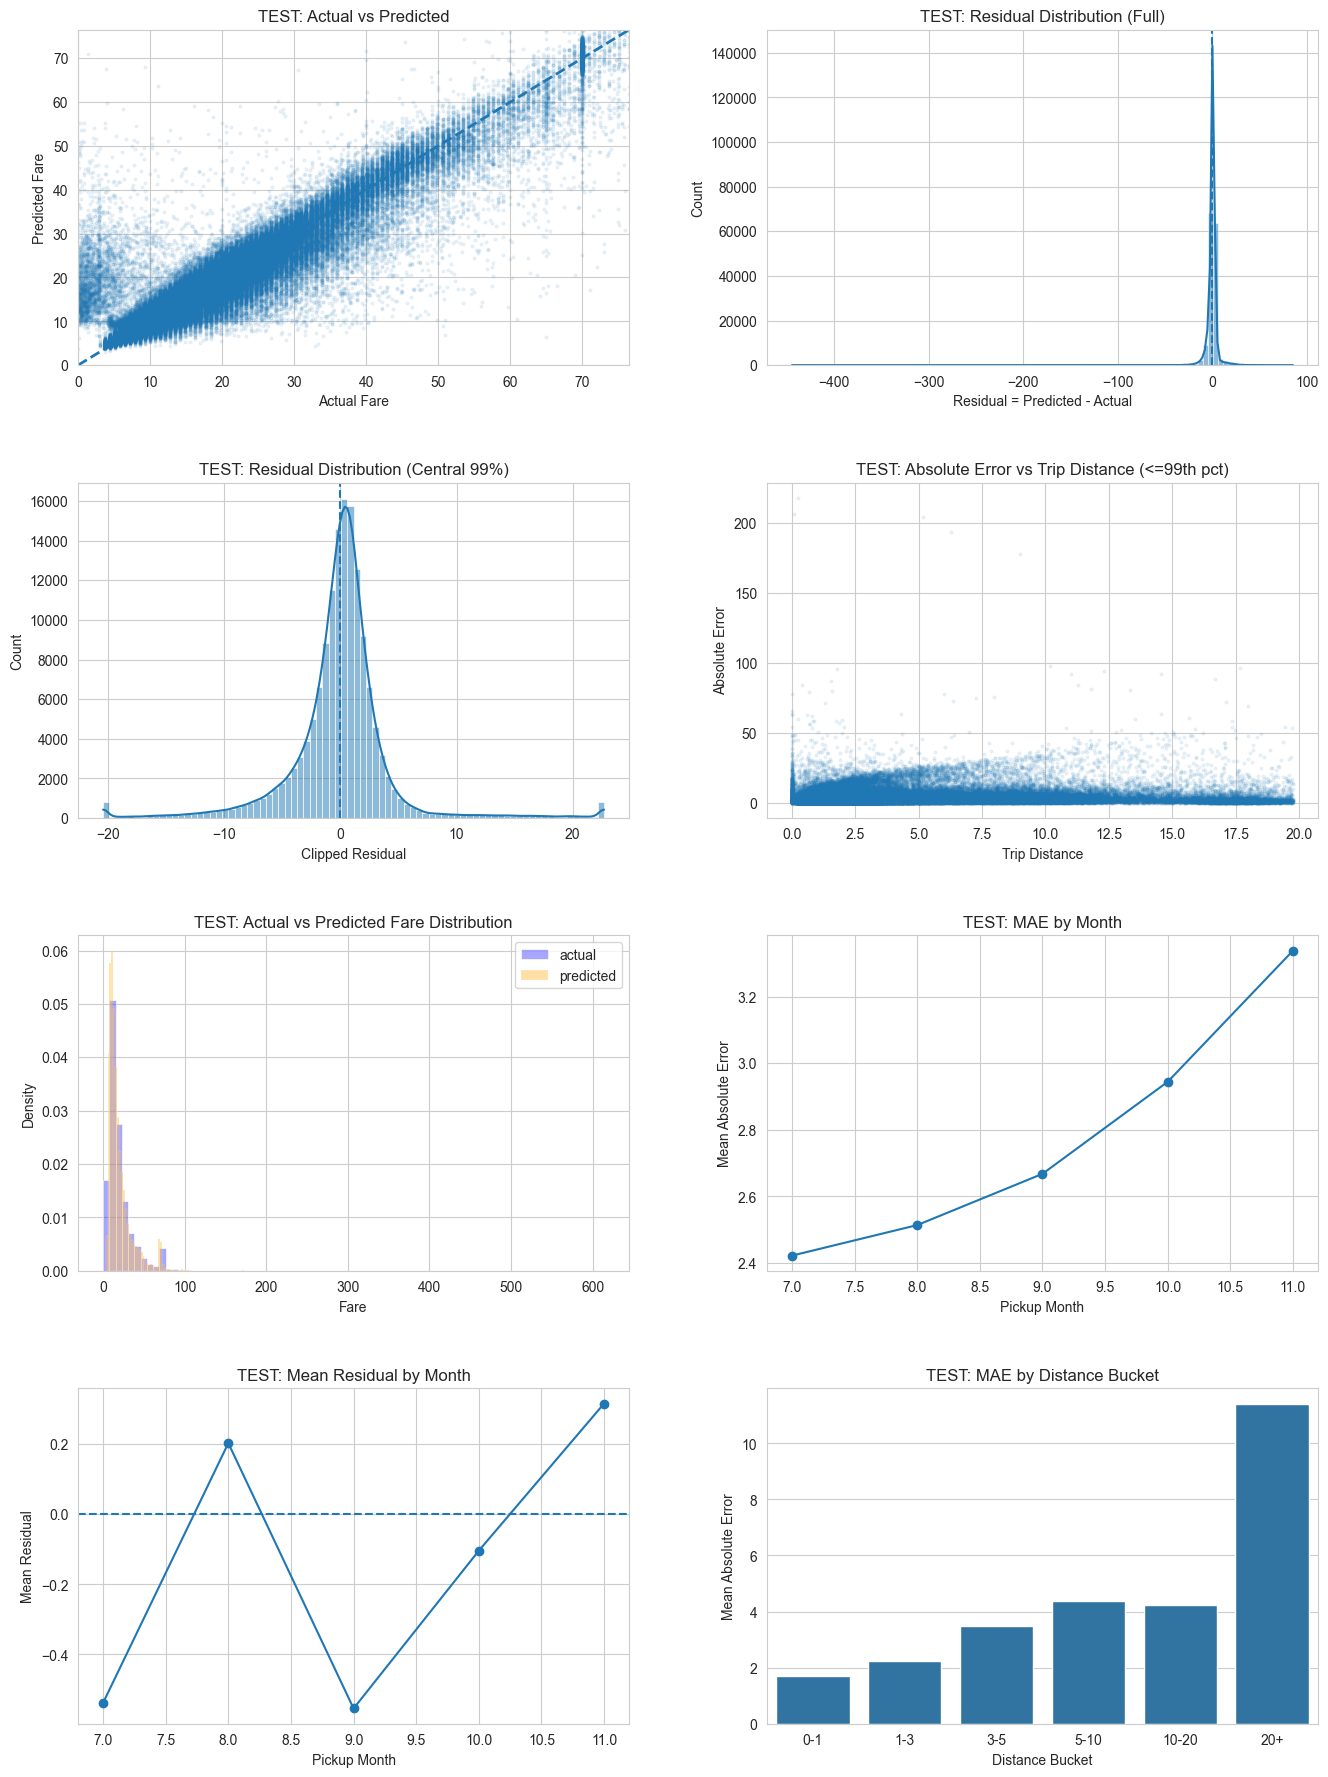

--- TEST DIAGNOSTIC SUMMARY ---
Rows: 150,000
MAE: 2.7771
RMSE: 5.6806
Mean residual (bias): -0.1355
Median absolute error: 1.5019
Actual min/max: 0.0100 / 614.1000
Predicted min/max: 3.0927 / 193.7785
99th pct abs error: 21.7649
Monthly MAE drift (first month -> last month): 37.81%

Top 10 worst rows by squared error:
 actual  predicted    residual  abs_error  trip_distance  PULocationID  DOLocationID  pickup_month
 614.10 169.430664 -444.669336 444.669336          91.15           132           265             8
 536.40 170.742218 -365.657782 365.657782          87.25           219           265            10
 440.00 163.746170 -276.253830 276.253830          70.69           143           265             9
 260.00  41.897327 -218.102673 218.102673           0.24            68           186            10
 221.62  15.175158 -206.444842 206.444842           0.10            79           265             9
 379.60 173.504669 -206.095331 206.095331          60.88           132           265 

In [68]:

test_results, test_diag = run_full_diagnostics(
    pipeline=pipeline,
    X_eval=X_test,
    y_eval=y_test,
    df_full_context=te,
    split_name="test",
)